In [1]:
import numpy as np
from noise_seeds import generate_noise
from PIL import Image
import matplotlib.pyplot as plt
import datetime
import os
from data_management import remove_x
from scipy.stats import linregress


# august 11th

In [2]:
black_frames = np.full((144, 256), fill_value = 0)

In [3]:
dynamic3 = generate_noise('dynamic', 1, 3)
dynamic3 = np.squeeze(dynamic3)

In [4]:
final_array = (black_frames + dynamic3)

In [5]:
final_array

array([[-1.39106973,  2.93475534,  0.97061978, ...,  2.89991911,
         1.13355965, -1.10606294],
       [-0.2641801 , -3.19742117,  1.21731814, ..., -4.18216912,
        -6.94544732, -3.62635224],
       [-3.35312715,  3.69394556,  2.34711808, ...,  0.03529587,
         1.48389353, -1.3159068 ],
       ...,
       [-4.27844083,  4.3928105 , -2.26643658, ...,  0.58566629,
         2.82686912,  7.00445435],
       [-0.37785696, -2.64463703,  2.90684498, ...,  1.24718284,
         3.55842674,  0.44063011],
       [ 0.08391263, -1.77024955,  3.89227117, ..., -0.98394486,
        -5.46384776, -7.55160245]])

In [6]:
final_array = np.round(final_array)

In [7]:
final_array

array([[-1.,  3.,  1., ...,  3.,  1., -1.],
       [-0., -3.,  1., ..., -4., -7., -4.],
       [-3.,  4.,  2., ...,  0.,  1., -1.],
       ...,
       [-4.,  4., -2., ...,  1.,  3.,  7.],
       [-0., -3.,  3., ...,  1.,  4.,  0.],
       [ 0., -2.,  4., ..., -1., -5., -8.]])

In [8]:
final_image = np.clip(final_array, a_min = 0, a_max = 255)

In [9]:
final_image

array([[0., 3., 1., ..., 3., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 4., 2., ..., 0., 1., 0.],
       ...,
       [0., 4., 0., ..., 1., 3., 7.],
       [0., 0., 3., ..., 1., 4., 0.],
       [0., 0., 4., ..., 0., 0., 0.]])

In [10]:
final_astype = final_image.astype('uint8')
final_astype

array([[0, 3, 1, ..., 3, 1, 0],
       [0, 0, 1, ..., 0, 0, 0],
       [0, 4, 2, ..., 0, 1, 0],
       ...,
       [0, 4, 0, ..., 1, 3, 7],
       [0, 0, 3, ..., 1, 4, 0],
       [0, 0, 4, ..., 0, 0, 0]], dtype=uint8)

In [11]:
image = Image.fromarray(final_image)

In [12]:
image.show()

In [13]:
np.max(black_frames + dynamic3)

np.float64(13.08144848736626)

# presentation plots

In [2]:
# in real code we now d3_labels from np.unique() on region label output from predictions
labels_lst = [1,2,3,4]

string_path = 'fnn//input_noise//saved_inputs_outputs//predictions_july21//'

for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
    for type_noise in ['_sum', '_mean', '_var', '_labels']:
        file_name = string_path + noise + type_noise + '.npy'
        arr_name = noise + type_noise
        globals()[arr_name] = np.load(file_name)

# load predictions by region
for r in labels_lst:
    for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin', 'no_noise']:
        for type_noise in ['_sum', '_mean', '_var']:
            file_name = string_path + noise + type_noise + '_r' + str(r) + '.npy'
            arr_name = noise + type_noise + '_r' + str(r)
            globals()[arr_name] = np.load(file_name)

In [3]:
dmeans1 = [[d3_mean_r1, d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dvars1 = [[d3_var_r1, d15_var_r1, d30_var_r1, dbin_var_r1],
               [d3_var_r2, d15_var_r2, d30_var_r2, dbin_var_r2],
               [d3_var_r3, d15_var_r3, d30_var_r3, dbin_var_r3],
               [d3_var_r4, d15_var_r4, d30_var_r4, dbin_var_r4]]

dmeans2 = [[d15_mean_r1, d30_mean_r1, dbin_mean_r1],
                 [d15_mean_r2, d30_mean_r2, dbin_mean_r2],
                 [d15_mean_r3, d30_mean_r3, dbin_mean_r3],
                 [d15_mean_r4, d30_mean_r4, dbin_mean_r4]]

dvars2 = [[d15_var_r1, d30_var_r1, dbin_var_r1],
               [d15_var_r2, d30_var_r2, dbin_var_r2],
               [d15_var_r3, d30_var_r3, dbin_var_r3],
               [d15_var_r4, d30_var_r4, dbin_var_r4]]

In [4]:
cmeans1 = [[c3_mean_r1, c15_mean_r1, c30_mean_r1, cbin_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2, cbin_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3, cbin_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4, cbin_mean_r4]]

cvars1 = [[c3_var_r1, c15_var_r1, c30_var_r1, cbin_var_r1],
               [c3_var_r2, c15_var_r2, c30_var_r2, cbin_var_r2],
               [c3_var_r3, c15_var_r3, c30_var_r3, cbin_var_r3],
               [c3_var_r4, c15_var_r4, c30_var_r4, cbin_var_r4]]

In [5]:
from visualizations import line_plot_mean, spike_plot_4x2, sixteen_tuning_curves, mean_var_scatter_4x4, mean_var_scatter_4x4_regression, violin_4row, violin_combined

#### spike plot

In [7]:
dmeans_spike = [[d3_mean_r1, d15_mean_r1, d30_mean_r1],
                 [d3_mean_r2, d15_mean_r2, d30_mean_r2],
                 [d3_mean_r3, d15_mean_r3, d30_mean_r3],
                 [d3_mean_r4, d15_mean_r4, d30_mean_r4]]


cmeans_spike = [[c3_mean_r1, c15_mean_r1, c30_mean_r1],
                 [c3_mean_r2, c15_mean_r2, c30_mean_r2],
                 [c3_mean_r3, c15_mean_r3, c30_mean_r3],
                 [c3_mean_r4, c15_mean_r4, c30_mean_r4]]

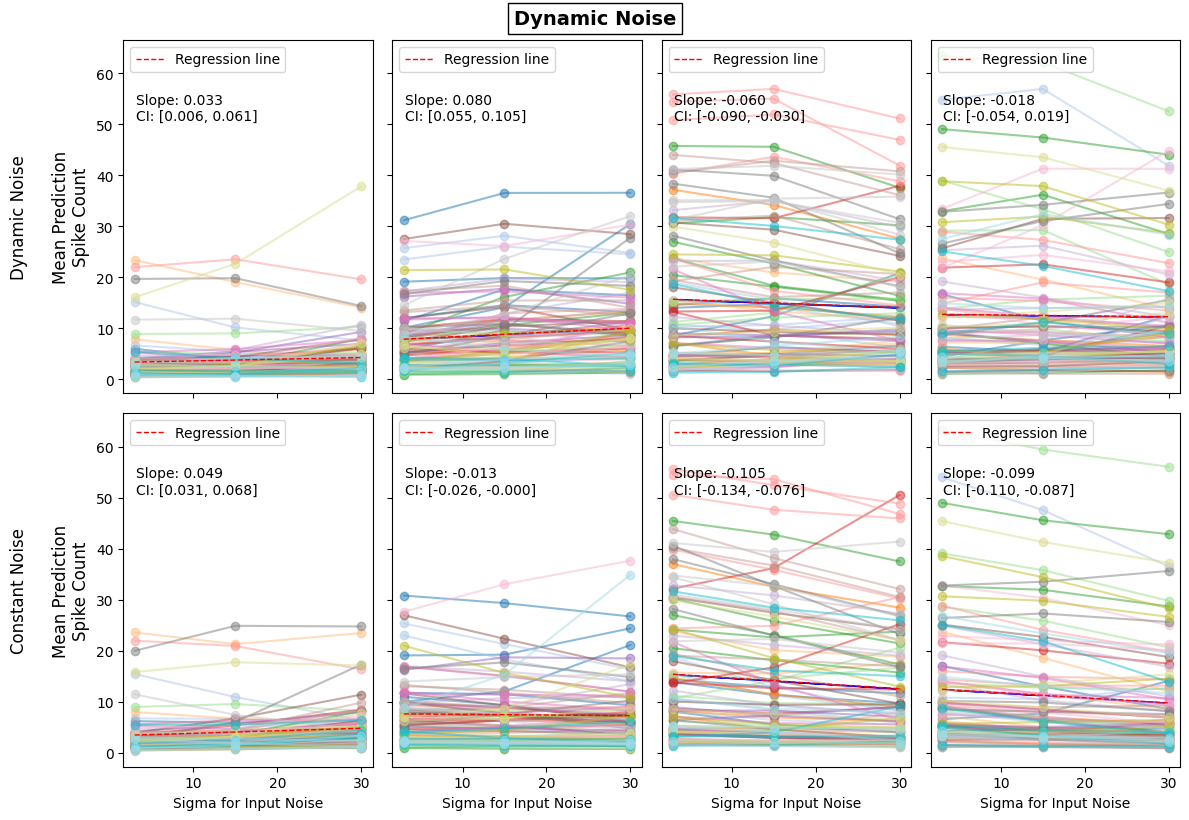

In [ ]:
spike_plot_4x2('Dynamic Noise', dmeans_spike, cmeans_spike, normalized = False)

#### tuning curves

In [15]:
ctuning_arrs = [[c3_sum_r1, c15_sum_r1, c30_sum_r1, cbin_sum_r1],
 [c3_sum_r2, c15_sum_r2, c30_sum_r2, cbin_sum_r2],
 [c3_sum_r3, c15_sum_r3, c30_sum_r3, cbin_sum_r3],
 [c3_sum_r4, c15_sum_r4, c30_sum_r4, cbin_sum_r4]]

dtuning_arrs = [[d3_sum_r1, d15_sum_r1, d30_sum_r1, dbin_sum_r1],
 [d3_sum_r2, d15_sum_r2, d30_sum_r2, dbin_sum_r2],
 [d3_sum_r3, d15_sum_r3, d30_sum_r3, dbin_sum_r3],
 [d3_sum_r4, d15_sum_r4, d30_sum_r4, dbin_sum_r4]]

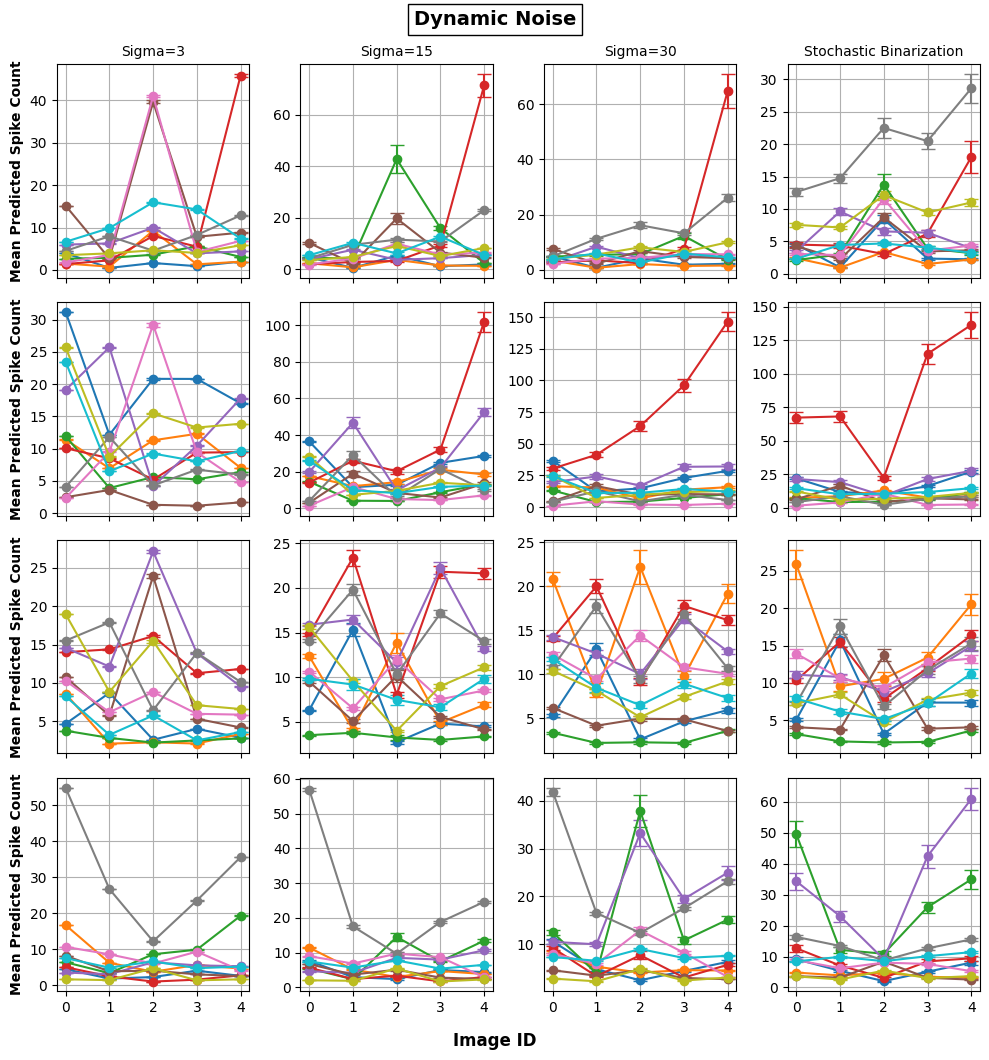

In [17]:
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

sixteen_tuning_curves(arrays = dtuning_arrs, main_title =  'Dynamic Noise',titles = titles, savefig = False )

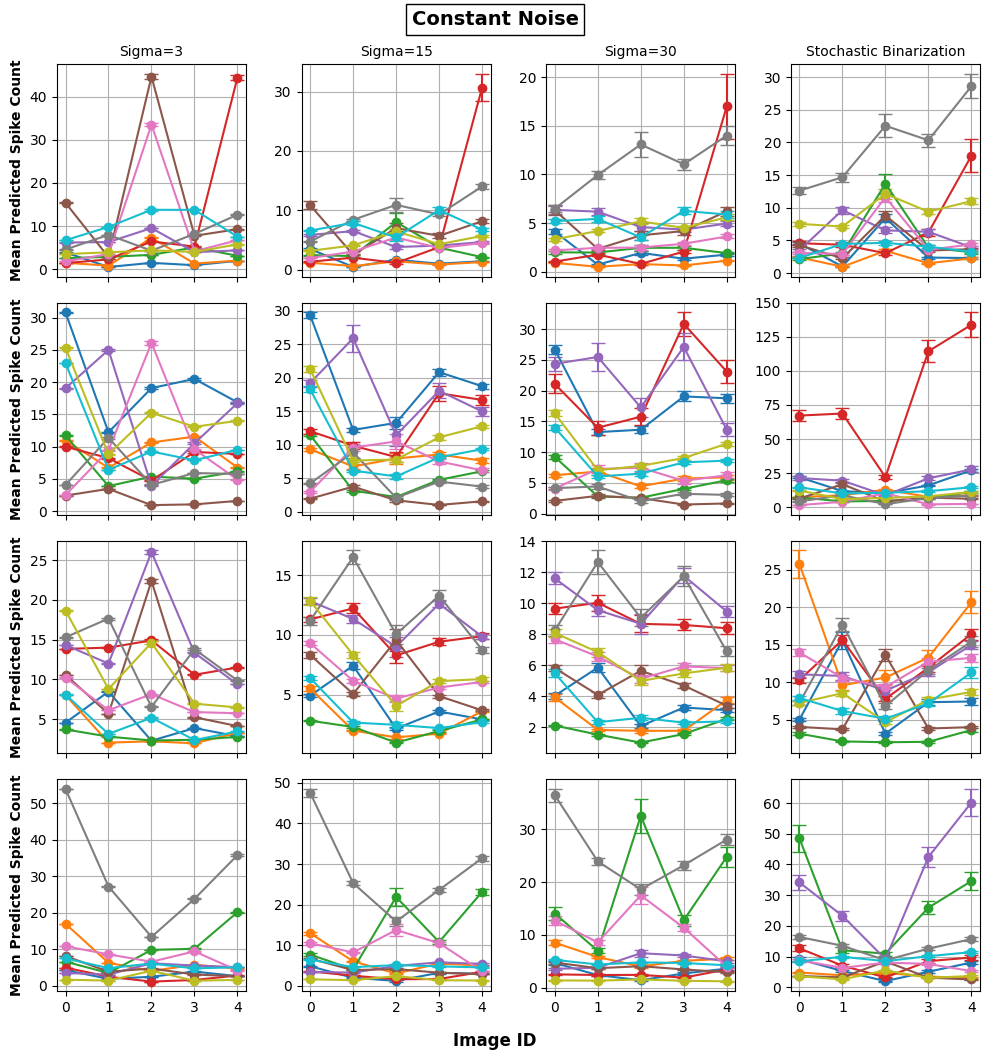

In [18]:
titles = ['Sigma=3', 'Sigma=15', 'Sigma=30', 'Stochastic Binarization']

sixteen_tuning_curves(arrays = ctuning_arrs, main_title =  'Constant Noise',titles = titles, savefig = False )

#### mean var scatter

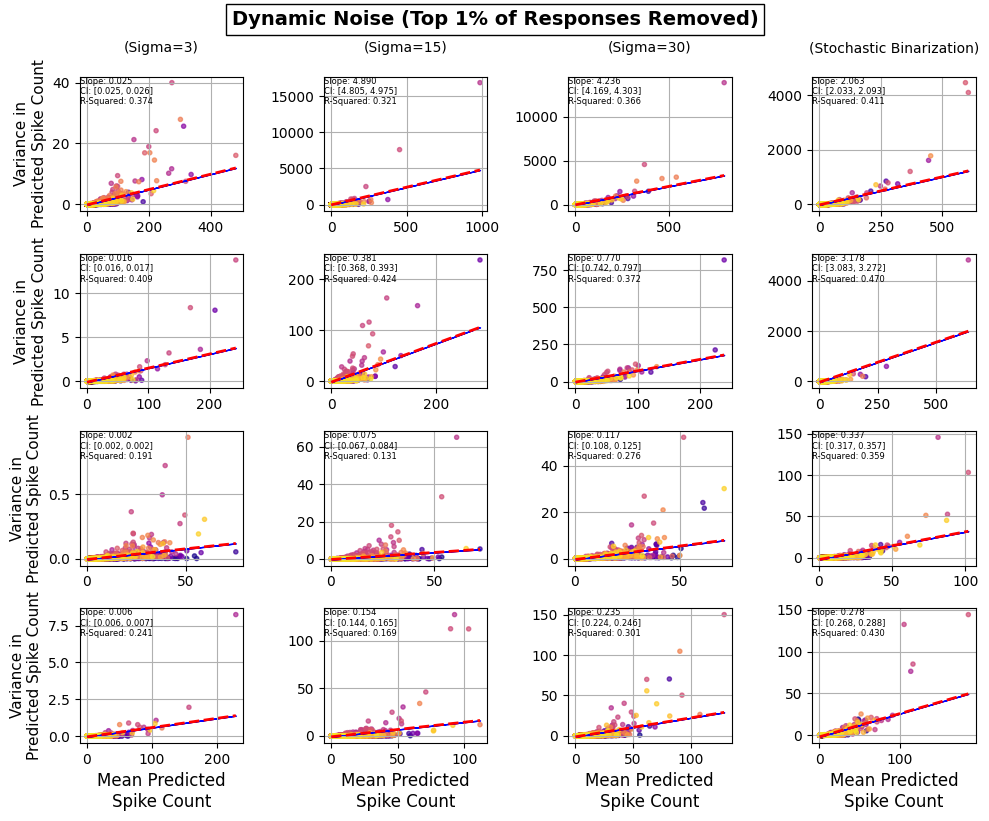

In [7]:
mean_var_scatter_4x4(means = cmeans1,vars = cvars1,main_title = 'Dynamic Noise (Top 1% of Responses Removed)', 
                     savefig = False)

#### mean var reg. 

In [8]:
# random neurons by region from last prediction 

# region 1
r1_randoms = [2322, 3279, 4060, 1756,  146, 4441, 3978, 2034, 5025, 3515, 3534,
       2167, 2310, 1837, 3864, 2529, 4127, 2325, 4791,  314, 3371, 1857,
       1095, 1917, 3097, 1722, 4344, 3627, 3930, 3459]
# region 2
r2_randoms = [958, 907, 514, 432, 594, 385, 184, 368, 525, 351, 302, 551, 550,
       575, 375, 719, 242, 613, 789, 872, 340, 402, 397, 643, 255, 928,
       471, 894, 281, 523]
# region 3
r3_randoms = [279, 337, 208, 128,  46, 115, 248, 197,  52, 269,  37, 364, 340,
       203,  36, 153,  84, 278,  71, 115,  24,  78, 138,  38,  22,  17,
        89, 349, 178, 332]
# region 4
r4_randoms = [376, 295, 517,  25, 663, 429, 427, 651, 133, 500, 689, 266, 470,
       424,  90, 560, 290, 198, 149, 181, 749, 461, 658, 771, 367, 758,
       125, 195, 191,   8]

In [9]:
randoms = [r1_randoms, r2_randoms, r3_randoms, r4_randoms]

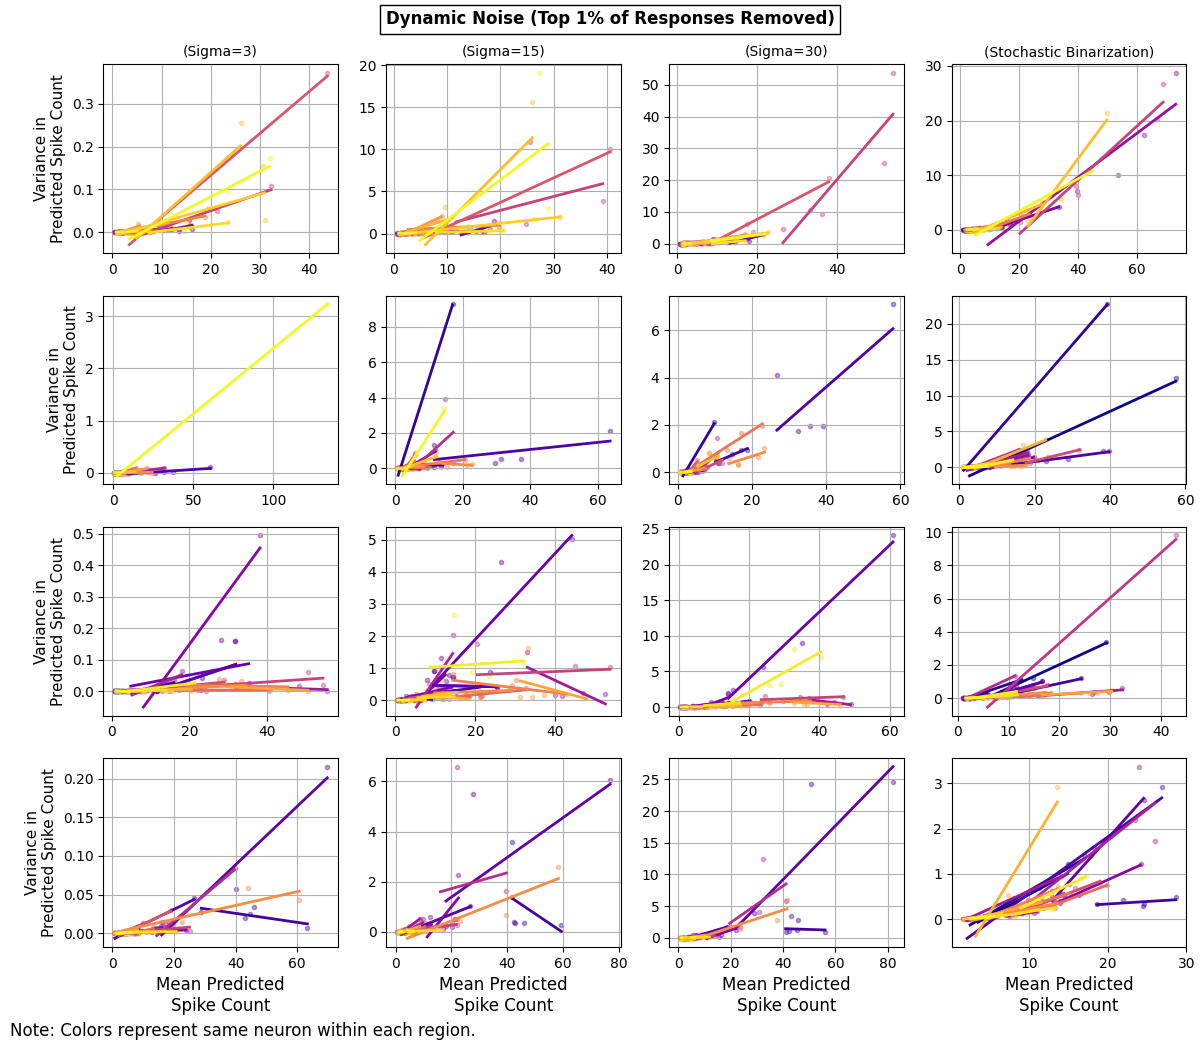

In [10]:
mean_var_scatter_4x4_regression(means = cmeans1,vars = cvars1, neurons = randoms, main_title = 'Dynamic Noise (Top 1% of Responses Removed)', 
                     savefig = False)

#### violin plot 1

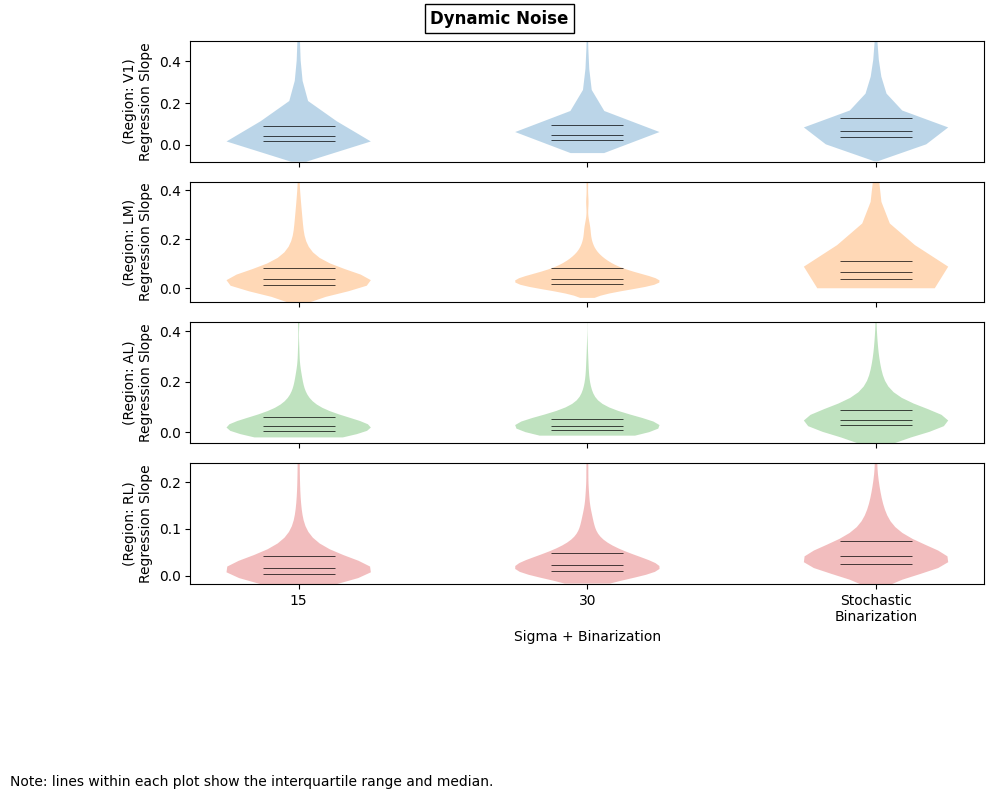

In [11]:
violin_4row(means = dmeans2, vars = dvars2, main_title = 'Dynamic Noise', savefig = False)

#### violin plot 2

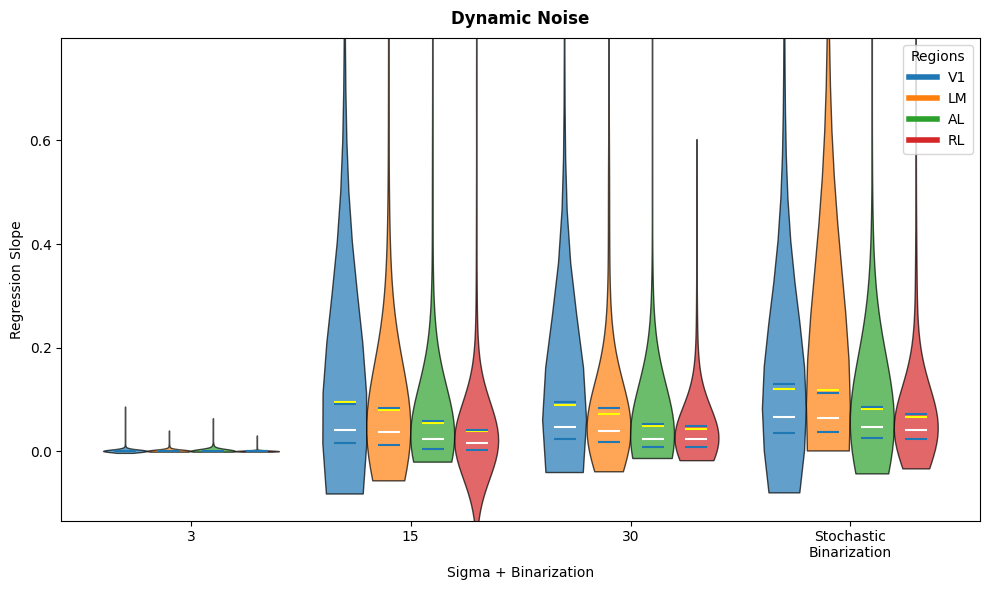

In [12]:
violin_combined(dmeans1, dvars1, 'Dynamic Noise', savefig = False)